# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [138]:

import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
import math
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

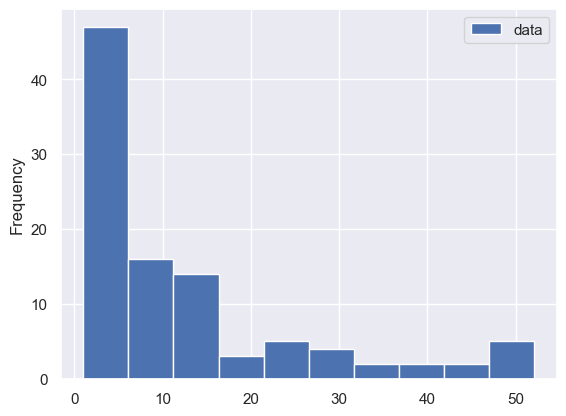

In [139]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

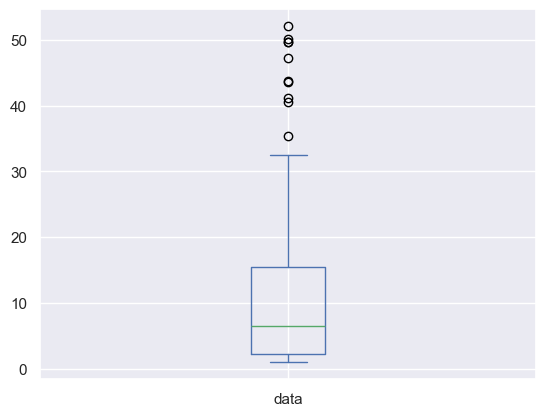

In [140]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [141]:
import warnings
import matplotlib.pyplot as plt

# Configs
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')


# read the datasets and save into dataframe
obesity_df =  pd.read_csv('datasets/ObesityDataSet_raw_and_data_sinthetic.csv')

# get categorical/object columns from dataframe
obesity_df_cat = obesity_df.select_dtypes(include=['category', 'object'])



In [142]:
# Generate info for each dataframe 
obesity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [143]:
columns = obesity_df.columns

In [144]:
# Find unique values of object / categorical variables

for col in columns:
    if obesity_df[col].dtype == 'O':
        _ = obesity_df[col].unique()
        print(f"{col} Unique Types: ", _)

Gender Unique Types:  ['Female' 'Male']
family_history_with_overweight Unique Types:  ['yes' 'no']
FAVC Unique Types:  ['no' 'yes']
CAEC Unique Types:  ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE Unique Types:  ['no' 'yes']
SCC Unique Types:  ['no' 'yes']
CALC Unique Types:  ['no' 'Sometimes' 'Frequently' 'Always']
MTRANS Unique Types:  ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
NObeyesdad Unique Types:  ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [145]:
obesity_df.duplicated().sum()
obesity_df.drop_duplicates()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [146]:
# Encome and map gender

obesity_df['Gender'] = obesity_df['Gender'].map({'Male': 1, 'Female': 0})


binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

# Map the binary columns
for col in binary_cols:
    obesity_df[col] = obesity_df[col].map({'yes': 1, 'no': 0})
    

# Define the order for CAEC and CALC
order_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity_df['CAEC'] = obesity_df['CAEC'].map(order_map)
obesity_df['CALC'] = obesity_df['CALC'].map(order_map)

# Define the order for the Target Variable (NObeyesdad)
obesity_map = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
obesity_df['NObeyesdad'] = obesity_df['NObeyesdad'].map(obesity_map)

# Create dummy variables for Transportation
# drop_first=True is used to prevent the 'dummy variable trap' (collinearity)


In [147]:
obesity_df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,1,0,2.000000,0,0.000000,1.000000,0,Public_Transportation,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,1,1,3.000000,1,3.000000,0.000000,1,Public_Transportation,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,1,0,2.000000,0,2.000000,1.000000,2,Public_Transportation,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,1,0,2.000000,0,2.000000,0.000000,2,Walking,2
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,1,0,2.000000,0,0.000000,0.000000,1,Public_Transportation,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1,0,1.728139,0,1.676269,0.906247,1,Public_Transportation,6
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1,0,2.005130,0,1.341390,0.599270,1,Public_Transportation,6
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1,0,2.054193,0,1.414209,0.646288,1,Public_Transportation,6
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1,0,2.852339,0,1.139107,0.586035,1,Public_Transportation,6


<Figure size 2000x2000 with 0 Axes>

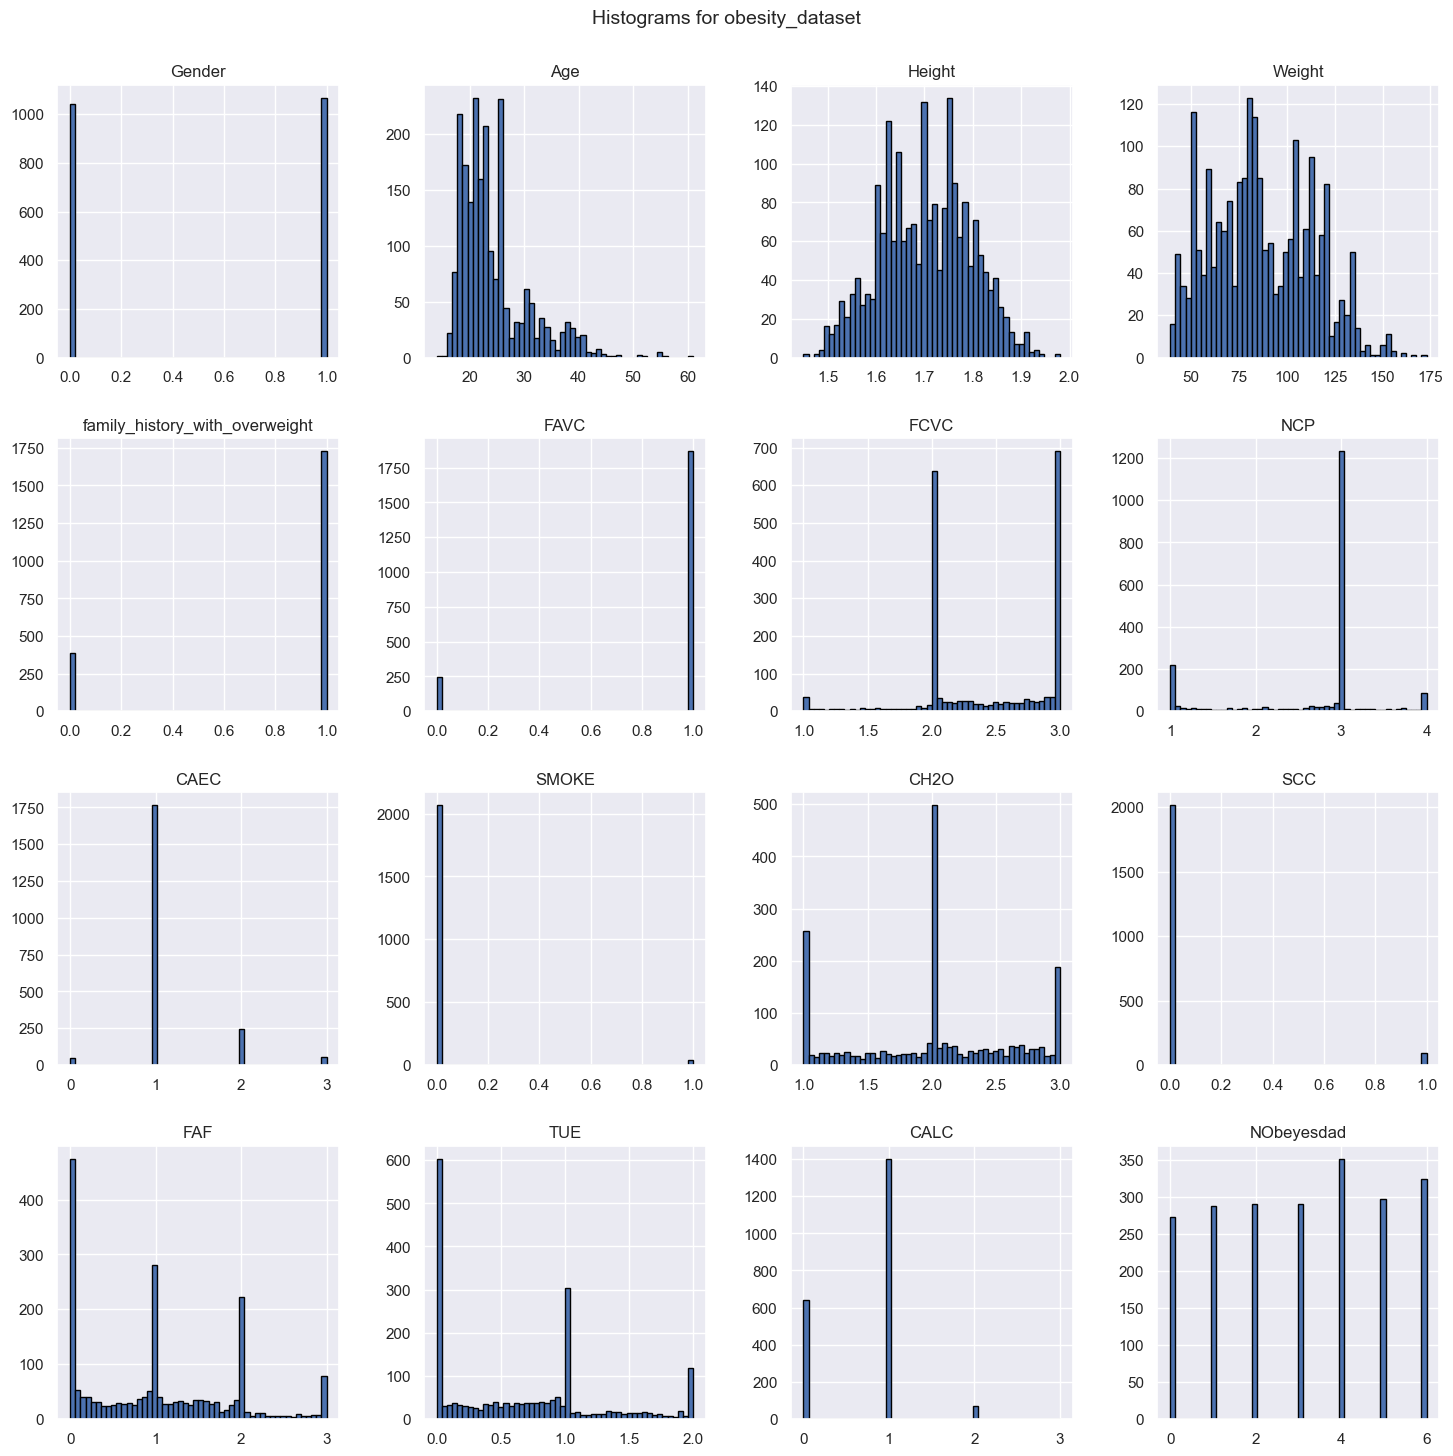

In [148]:

plt.figure(figsize=(20, 20)) 
obesity_df.hist(bins=50, figsize=(15, 15), edgecolor='black') 
plt.suptitle(f"Histograms for obesity_dataset", fontsize=14) 
plt.tight_layout(pad=2.0) 
plt.show()

<Axes: >

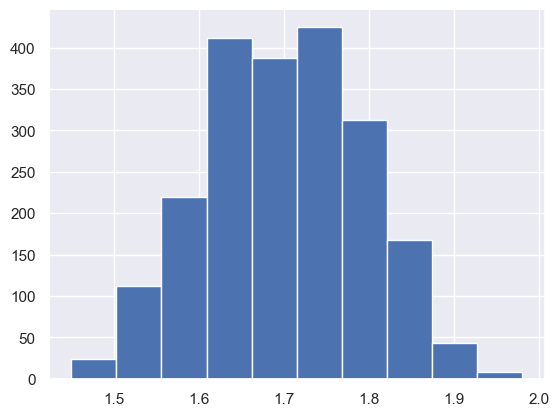

In [149]:
# Cleaning some of the data so histograms are cleaner/more accurate.
obesity_df['Age'] = obesity_df['Age'].round(0)
obesity_df['Height'].hist()

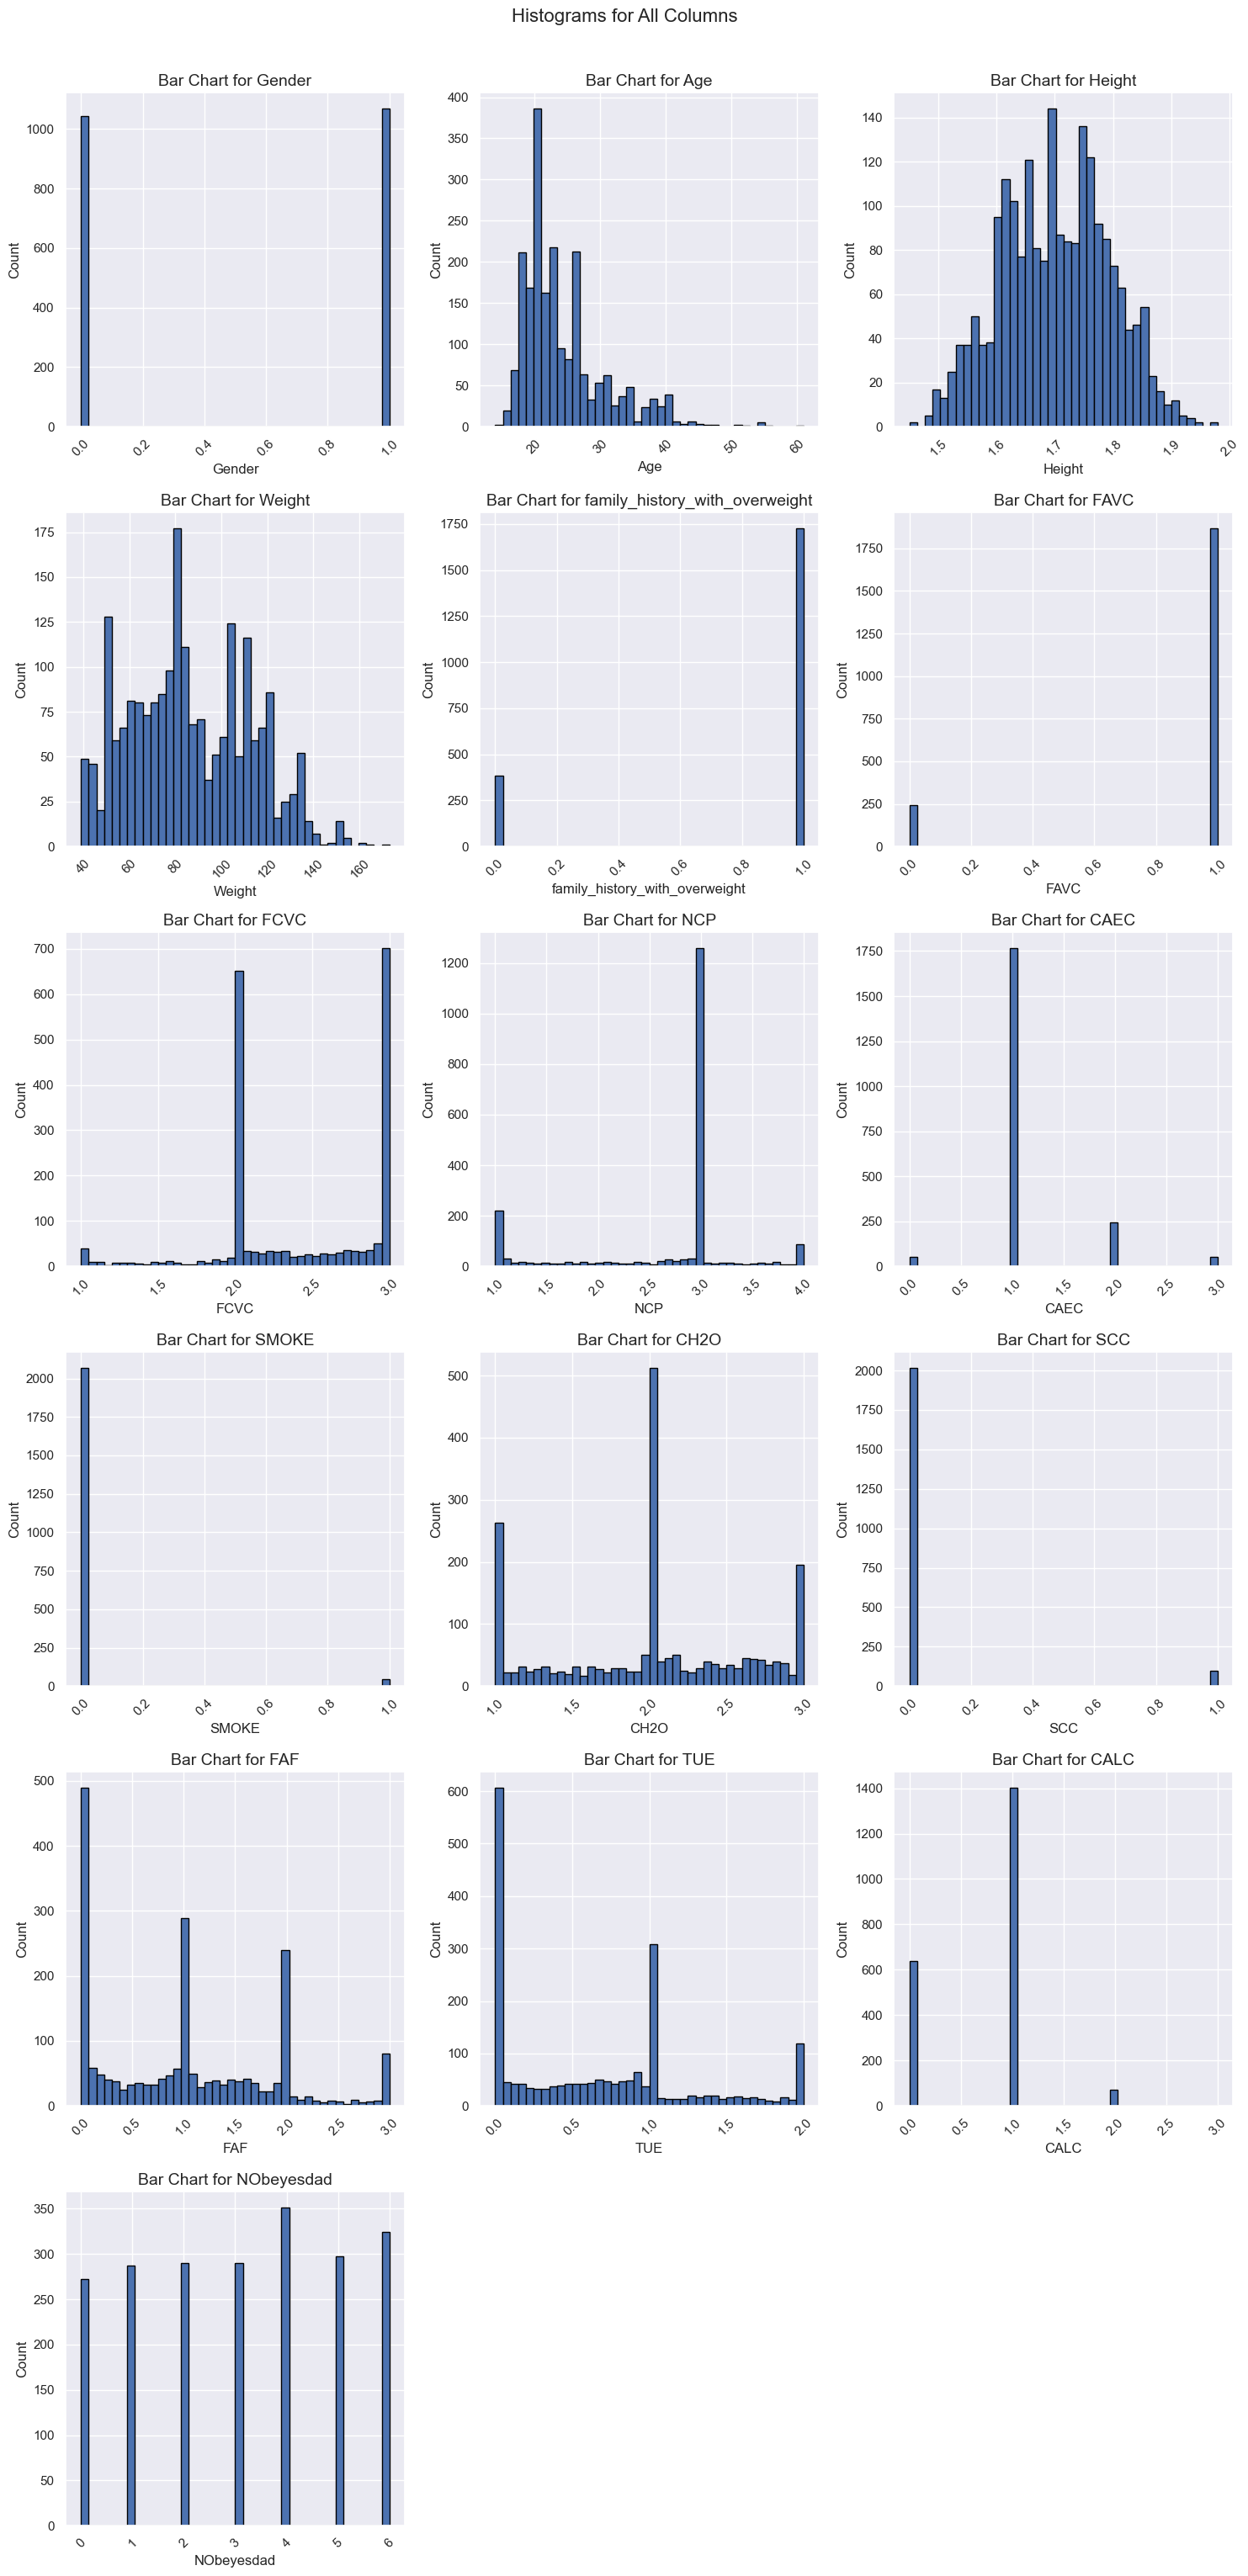

In [151]:


# Determine the number of columns and rows for subplots
numeric_cols = obesity_df.select_dtypes(include=['number']).columns
num_cols = len(obesity_df.columns)
cols = 3 
rows = math.ceil(num_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for i, col in enumerate(numeric_cols):
    obesity_df[col].hist(bins=40, ax=axes[i], edgecolor='black')
    axes[i].set_title(f"Bar Chart for {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Histograms for All Columns", fontsize=16, y=1.02)
plt.show()


In [152]:
obesity_df.describe()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,0.505921,24.315964,1.701677,86.586058,0.817622,0.883941,2.419043,2.685628,1.140692,0.020843,2.008011,0.045476,1.010298,0.657866,0.731407,3.112269
std,0.500083,6.357078,0.093305,26.191172,0.386247,0.320371,0.533927,0.778039,0.468543,0.142893,0.612953,0.208395,0.850592,0.608927,0.515498,1.985062
min,0.000000,14.000000,1.450000,39.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,1.630000,65.473343,1.000000,1.000000,2.000000,2.658738,1.000000,0.000000,1.584812,0.000000,0.124505,0.000000,0.000000,1.000000
50%,1.000000,23.000000,1.700499,83.000000,1.000000,1.000000,2.385502,3.000000,1.000000,0.000000,2.000000,0.000000,1.000000,0.625350,1.000000,3.000000
75%,1.000000,26.000000,1.768464,107.430682,1.000000,1.000000,3.000000,3.000000,1.000000,0.000000,2.477420,0.000000,1.666678,1.000000,1.000000,5.000000
max,1.000000,61.000000,1.980000,173.000000,1.000000,1.000000,3.000000,4.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,3.000000,6.000000


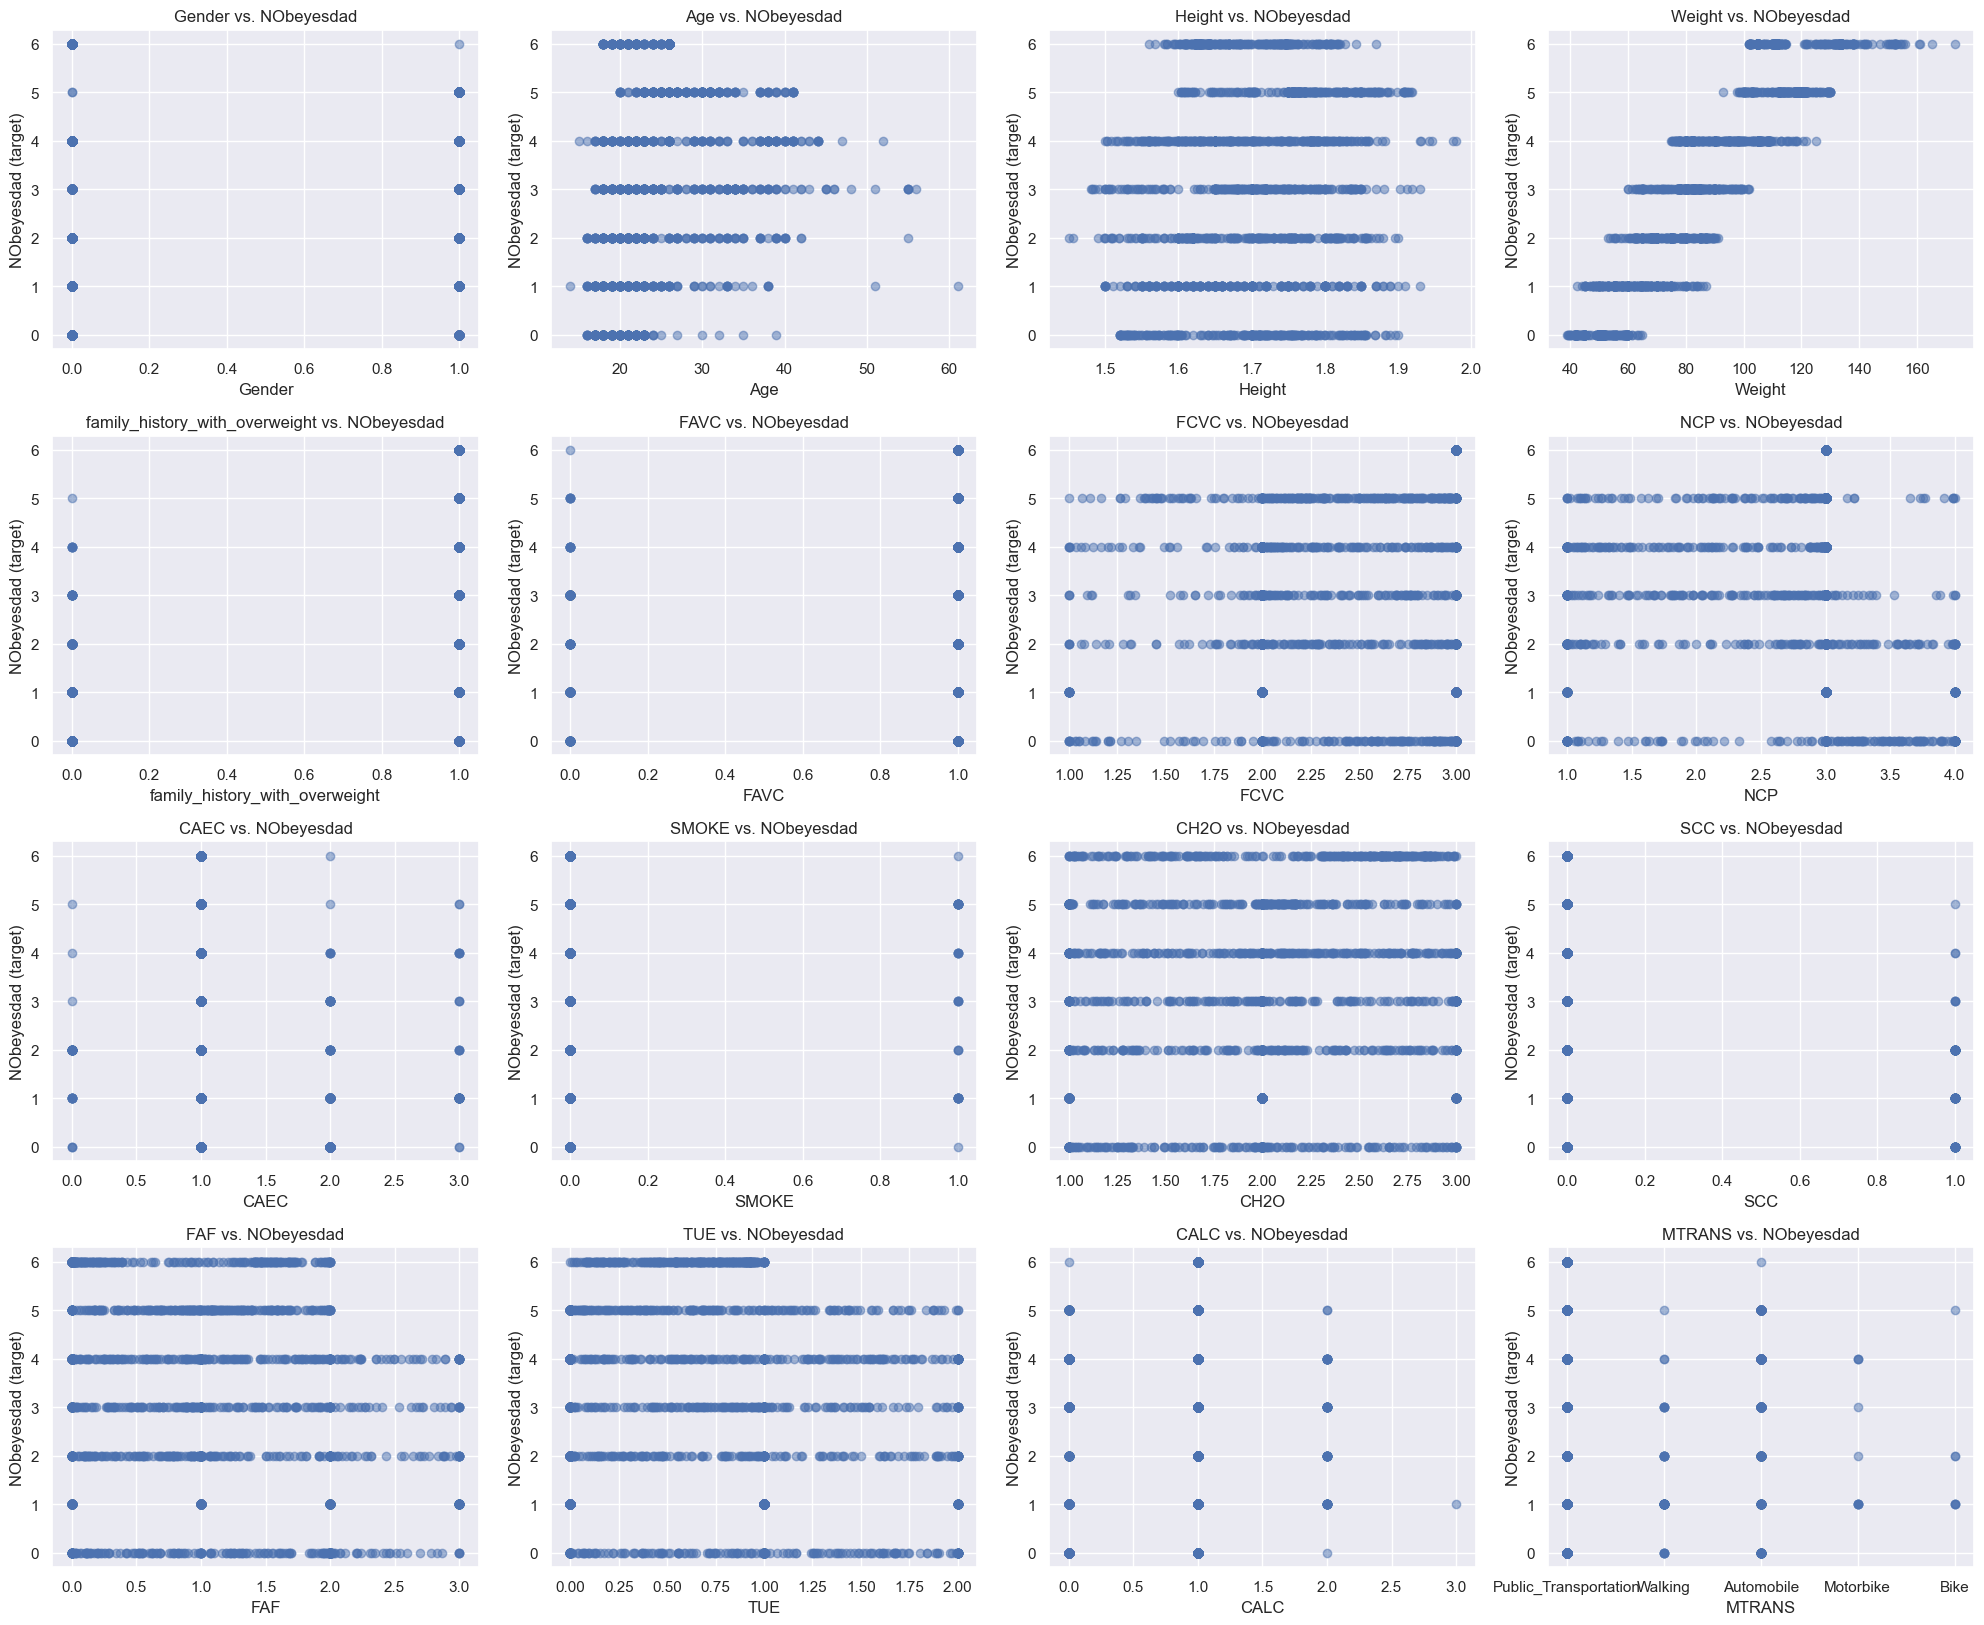

In [ ]:
obesity_df_features = obesity_df.drop('NObeyesdad', axis=1)
target = obesity_df['NObeyesdad']

# plot all features against the target variable
plt.figure(figsize=(20, 20))

for i, column in enumerate(obesity_df_features.columns):
    plt.subplot(5, 4, i + 1)
    plt.scatter(obesity_df_features[column], target, alpha=0.5)
    plt.title(column+' vs. '+ 'NObeyesdad')
    plt.xlabel(column)
    plt.ylabel('NObeyesdad (target)')
    plt.tight_layout()

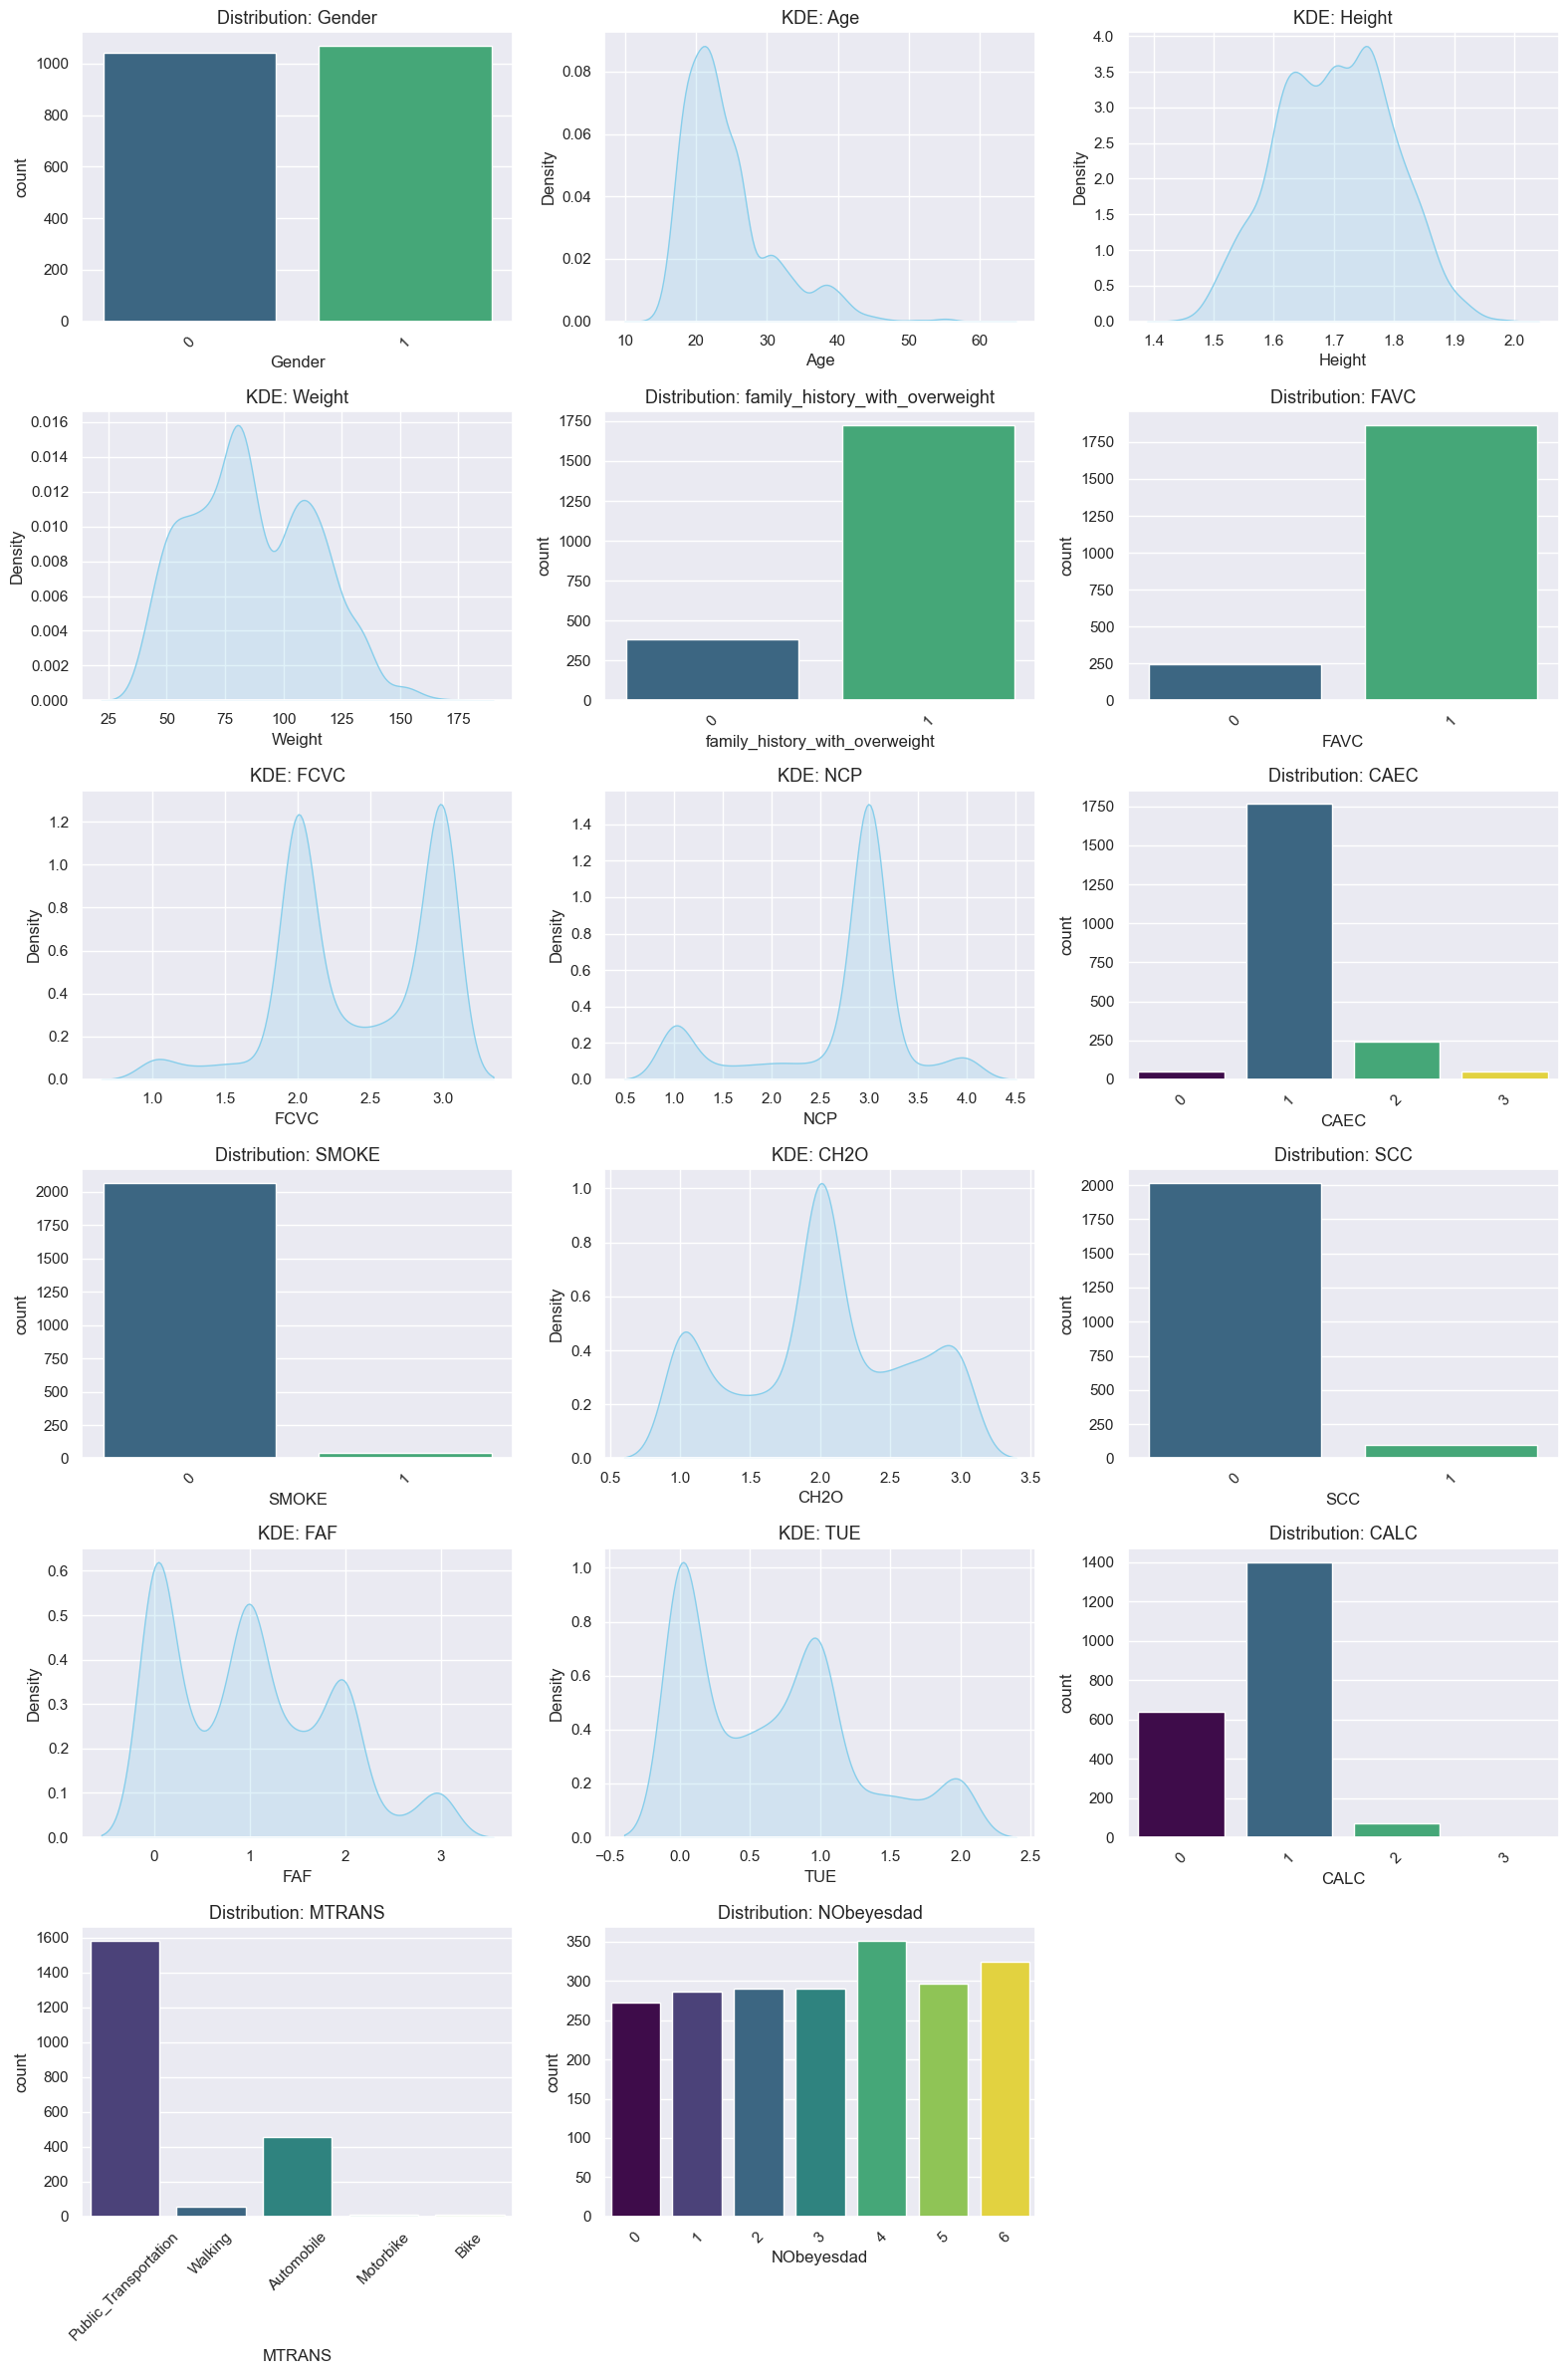

In [154]:
# Using seaborn to look at KDE or count plots depending on the column type

sns.set_theme()

cols = 3
rows = math.ceil(len(obesity_df.columns) / cols)
fig = plt.figure(figsize=(16, rows * 4))

for i, col in enumerate(obesity_df.columns):
    # Add subplot 'just-in-time' (no cleanup needed)
    ax = fig.add_subplot(rows, cols, i + 1)
    
    # Logic: KDE for continuous, Countplot for categorical/binary
    is_numeric = obesity_df[col].dtype.kind in 'if'
    is_continuous = obesity_df[col].nunique() > 10 # adjustable threhsold 
    
    if is_numeric and is_continuous:
        sns.kdeplot(data=obesity_df, x=col, fill=True, color="skyblue", ax=ax)
        ax.set_title(f"KDE: {col}", fontsize=13)
    else:
        # Treats Object, Category, Binary, and low-range Integers as categories
        sns.countplot(data=obesity_df, x=col, hue=col, palette="viridis", ax=ax, legend=False)
        ax.set_title(f"Distribution: {col}", fontsize=13)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [168]:
obesity_df['MTRANS'].value_counts()

MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

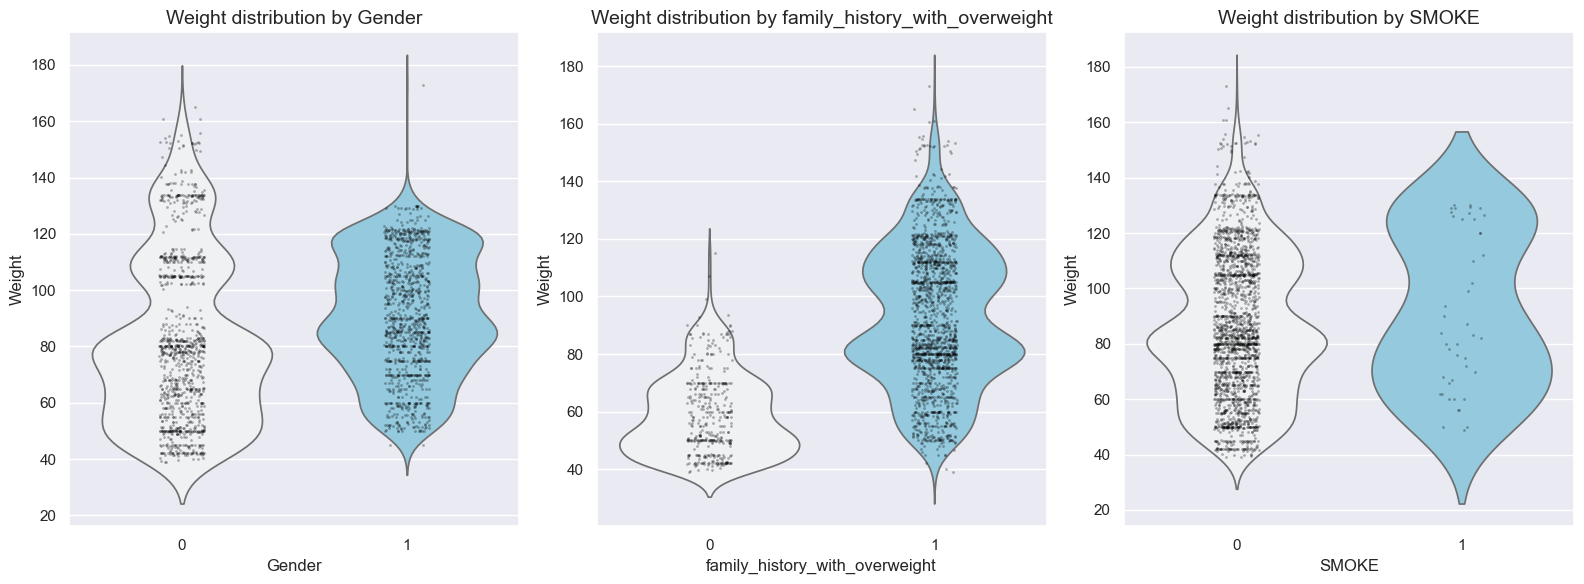

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

# Features to compare against Weight
categories = ['Gender', 'family_history_with_overweight', 'SMOKE']
target = 'Weight'

fig = plt.figure(figsize=(16, 6))

for i, col in enumerate(categories):
    ax = fig.add_subplot(1, len(categories), i + 1)
    
    # Violin Plot (shows the "shape" of the data)
    sns.violinplot(data=obesity_df, x=col, y=target, inner=None, 
                   palette="light:skyblue", ax=ax)
    
    # Strip Plo overlayed (shows every single individual)
    sns.stripplot(data=obesity_df, x=col, y=target, 
                  color="black", size=2, alpha=0.3, jitter=True, ax=ax)
    
    ax.set_title(f'{target} distribution by {col}', fontsize=14)

plt.tight_layout()
plt.show()

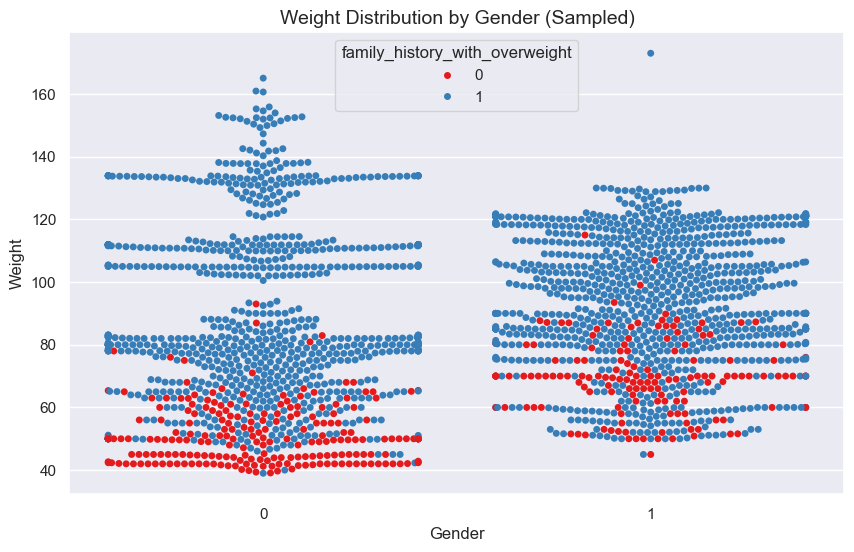

In [156]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=obesity_df, x='Gender', y='Weight', hue='family_history_with_overweight', palette='Set1', size=5)
plt.title("Weight Distribution by Gender (Sampled)", fontsize=14)
plt.show()

In [157]:
# calculate the mean and median for all numeric columns, then identifty the mode for all columns.
means = obesity_df.mean(numeric_only=True)
medians = obesity_df.median(numeric_only=True)
mins = obesity_df.min(numeric_only=True)
maxs = obesity_df.max(numeric_only=True)
modes = obesity_df.mode().iloc[0] 

summary_df = pd.DataFrame([means, medians, modes, mins, maxs], index=['mean', 'median', 'mode', 'min', 'max'])
summary_df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS
mean,0.505921,24.315964,1.701677,86.586058,0.817622,0.883941,2.419043,2.685628,1.140692,0.020843,2.008011,0.045476,1.010298,0.657866,0.731407,3.112269,NaN
median,1.000000,23.000000,1.700499,83.000000,1.000000,1.000000,2.385502,3.000000,1.000000,0.000000,2.000000,0.000000,1.000000,0.625350,1.000000,3.000000,NaN
mode,1.000000,21.000000,1.700000,80.000000,1.000000,1.000000,3.000000,3.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,4.000000,Public_Transportation
min,0.000000,14.000000,1.450000,39.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,1.000000,61.000000,1.980000,173.000000,1.000000,1.000000,3.000000,4.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,3.000000,6.000000,NaN


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### My Conclusions 

> Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- The data does seem usable. There is a mix of feature types in this dataset. The target variable is categorical with an ordinal nature. I would imagine a decision tree type of model would likely be the most effective here. 

> What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- There are a mix of distributions. Height has the most normal distribution. Weight has a left skew distribution.  
- There are features that have bimodal distributions such as FCVC (frequency of vegetables in meals). Features like FAF (frequency of phsical activity) have a multi-modal distribution with a bit of a left skew.

> Are there any outliers present?  (Data points that are far from the others.)
- Yes there are outliers in some of the data. For example lots more non-smokers than smokers. 

> If there are multiple related histograms, how does the distribution change across different groups?
- Yes, For example there are a lot more type 3 obese (more significantly overweight) females relative to the males as seen above when comparing genders in the violin plot overlayed by the strip plot. 
-  We see different distributions in `Weight` by `family_history_with_overweight`. Those with a history of overweight tend to have more 

> What are the minimum and maximum values represented in each histogram?
- Refer to the `summary_df` above.

> How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
- the greater the bins the less fidelity seen on the distribution and the less it is subject to noise fluctuations. 

> Does the distribution appear normal, or does it have a different distribution?
- Answered above. Depends on the column. 

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

In [158]:
obesity_df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Public_Transportation,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Public_Transportation,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Public_Transportation,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Walking,2
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Public_Transportation,3
5,1,29.0,1.62,53.0,0,1,2.0,3.0,1,0,2.0,0,0.0,0.0,1,Automobile,1
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1,0,2.0,0,1.0,0.0,1,Motorbike,1
7,1,22.0,1.64,53.0,0,0,2.0,3.0,1,0,2.0,0,3.0,0.0,1,Public_Transportation,1
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1,0,2.0,0,1.0,1.0,2,Public_Transportation,1
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1,0,2.0,0,1.0,1.0,0,Public_Transportation,1


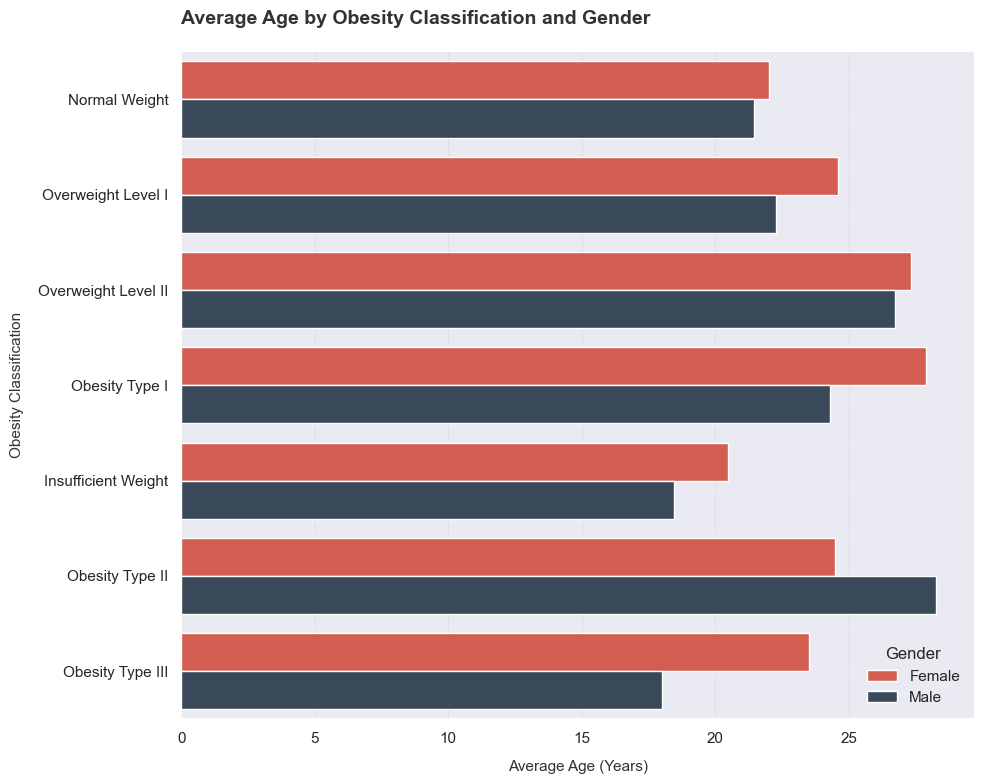

In [159]:
# 1. Map Gender to strings
obesity_df['Gender_Label'] = obesity_df['Gender'].map({0: 'Female', 1: 'Male'})

# 2. Map Obesity Levels back to readable strings (Adjust these keys if your encoding was different!)
obesity_mapping = {
    0: 'Insufficient Weight',
    1: 'Normal Weight',
    2: 'Overweight Level I',
    3: 'Overweight Level II',
    4: 'Obesity Type I',
    5: 'Obesity Type II',
    6: 'Obesity Type III'
}

obesity_df['Obesity_Class'] = obesity_df['NObeyesdad'].map(obesity_mapping)


# Choose distinct, professional colors
gender_palette = {"Male": "#34495e", "Female": "#e74c3c"}

# Initialize the figure size
plt.figure(figsize=(10, 8))

# --- CREATE THE PLOT ---
ax = sns.barplot(
    data=obesity_df,
    y='Obesity_Class',   # Use the new categorical string column!
    x='Age',
    hue='Gender_Label',  # Use the mapped Gender column!
    orient='h',
    palette=gender_palette,
    errorbar=None  
)

# Remove unnecessary chart borders (spines)
sns.despine(left=False, bottom=False)

# Add subtle vertical gridlines to help read the bar lengths
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
ax.set_axisbelow(True) 

# Clean Axis Labels
plt.ylabel("Obesity Classification", fontsize=11, color='#333333', labelpad=10) 
plt.xlabel("Average Age (Years)", fontsize=11, color='#333333', labelpad=10)

# Clean the Legend
plt.legend(
    title="Gender", 
    frameon=False, 
    loc='lower right'
)

# Title should be the main takeaway
plt.title(
    "Average Age by Obesity Classification and Gender",
    loc='left',
    fontsize=14,
    color='#333333',
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [160]:
obesity_df.MTRANS.unique()

array(['Public_Transportation', 'Walking', 'Automobile', 'Motorbike',
       'Bike'], dtype=object)

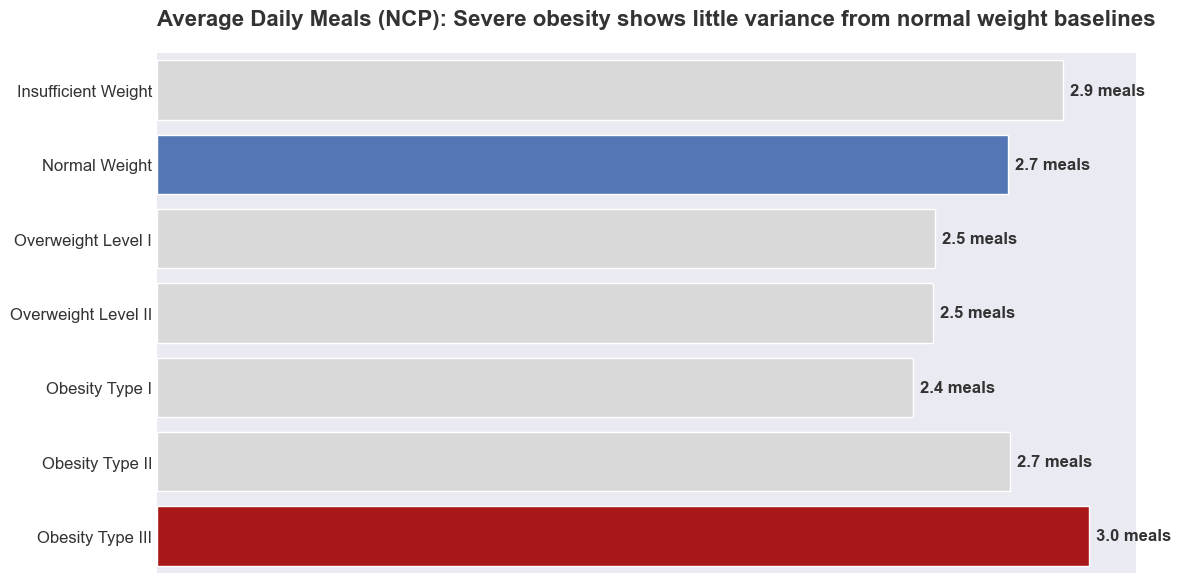

In [161]:
# 1. SWD STRATEGIC COLOR PALETTE
# Gray out the noise, highlight the specific comparison (Normal vs. Severe Obesity)
swd_meal_palette = {
    'Insufficient Weight': '#d9d9d9', # Light Gray
    'Normal Weight': '#4472c4',       # Baseline Highlight (Blue)
    'Overweight Level I': '#d9d9d9',  # Light Gray
    'Overweight Level II': '#d9d9d9', # Light Gray
    'Obesity Type I': '#d9d9d9',      # Light Gray
    'Obesity Type II': '#d9d9d9',     # Light Gray
    'Obesity Type III': '#c00000'     # Comparison Highlight (Red)
}

# Initialize the figure size
fig, ax = plt.subplots(figsize=(12, 6))

# --- CREATE THE PLOT ---
# sns.barplot automatically calculates the mean (average) for the X variable
sns.barplot(
    data=obesity_df,
    x='NCP',             # Numeric (Average daily meals)
    y='Obesity_Class',   # Categorical
    palette=swd_meal_palette,
    order=list(swd_meal_palette.keys()), # Keep ordinal sequence
    orient='h',
    errorbar=None,       # Remove error bars (reduces visual clutter)
    ax=ax
)

# --- SWD DECLUTTERING ---
# Remove ALL spines (borders) since we are using direct labels
sns.despine(left=True, bottom=True)

# Turn off the grid entirely
ax.xaxis.grid(False)
ax.yaxis.grid(False)

# Remove the tick marks (the little lines next to the words)
ax.tick_params(axis='both', length=0)

# Remove axis labels completely 
plt.xlabel("")
plt.ylabel("")

# Remove the X-axis numbers at the bottom (we will label the bars directly)
ax.set_xticklabels([])

# Format the Y-axis category text
plt.yticks(fontsize=12, color='#333333')

# --- SWD DIRECT DATA LABELS ---
# Put the exact average number of meals at the end of each bar
for p in ax.patches:
    width = p.get_width()
    # Only label bars that actually have data
    if width > 0:
        ax.annotate(f'{width:.1f} meals', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    fontsize=12, color='#333333', fontweight='bold',
                    xytext=(5, 0), textcoords='offset points')

# --- SWD ACTIVE TITLE ---
# Tell the story directly. (Update this text based on what the math actually reveals!)
plt.title(
    "Average Daily Meals (NCP): Severe obesity shows little variance from normal weight baselines", 
    loc='left',
    fontsize=16, 
    fontweight='bold', 
    color='#333333',
    pad=20
)

plt.tight_layout()
plt.show()

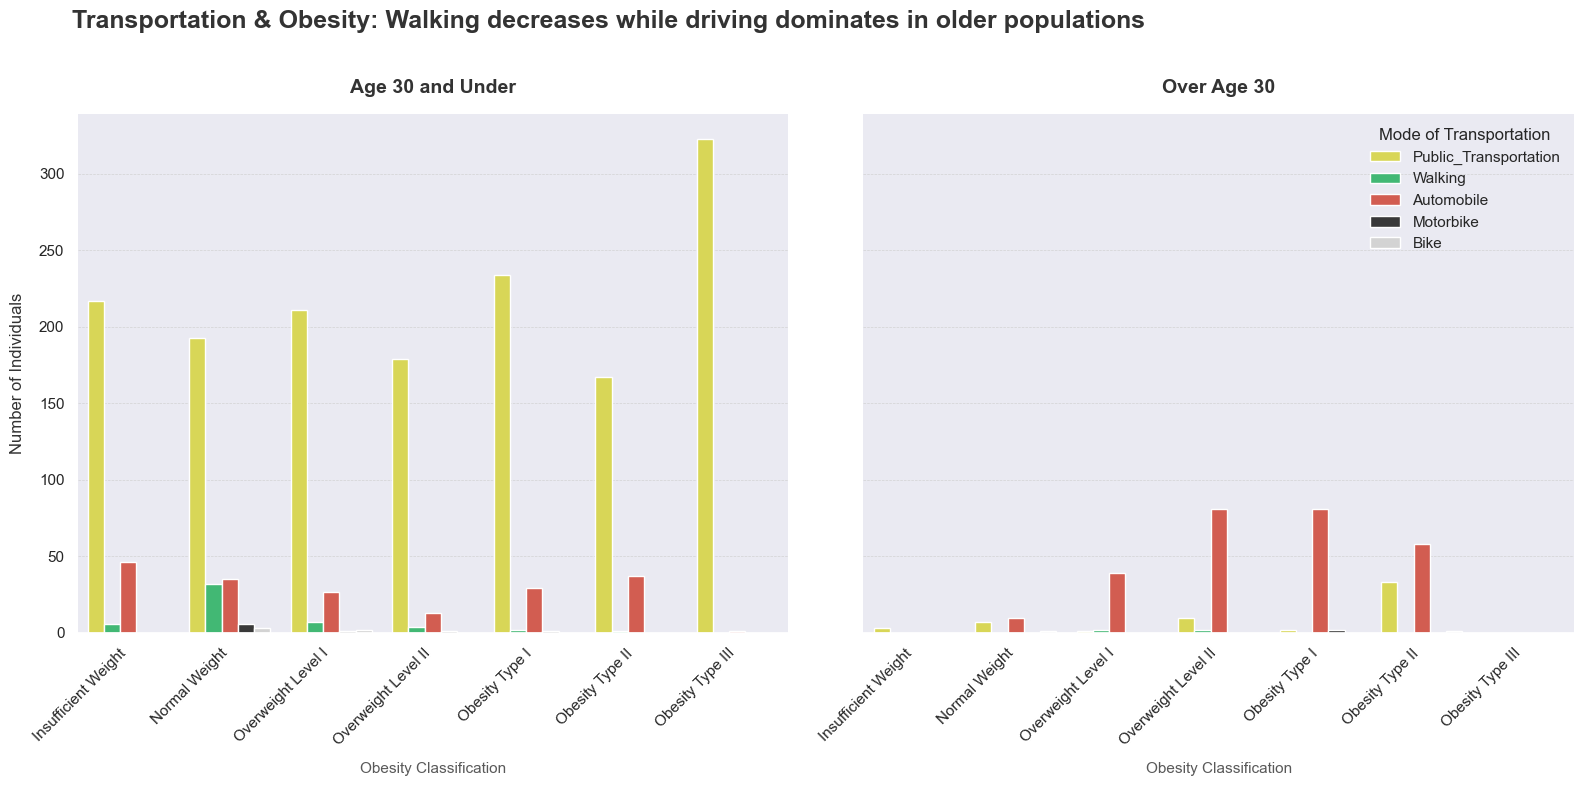

In [162]:
# --- 1. PREPROCESSING: SPLIT THE DATA ---
# Create two separate dataframes for our subplots
df_under_30 = obesity_df[obesity_df['Age'] <= 30]
df_over_30 = obesity_df[obesity_df['Age'] > 30]

# --- 2. COLOR PALETTE & ORDERING ---
mtrans_palette = {
    'Public_Transportation': "#eeeb41", # Light Gray
    'Walking': "#2ecc71",               # Green (Highlighted)
    'Automobile': "#e74c3c",            # Red (Highlighted)
    'Motorbike': "#393939",             # Light Gray
    'Bike': "#d3d3d3"                   # Light Gray
}

# Define the logical order of obesity classifications so both charts match perfectly
obesity_order = [
    'Insufficient Weight', 'Normal Weight', 'Overweight Level I', 
    'Overweight Level II', 'Obesity Type I', 'Obesity Type II', 'Obesity Type III'
]

# --- 3. INITIALIZE SUBPLOTS ---
# Create 1 row, 2 columns. sharey=True keeps the height scale identical for accurate comparison!
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- 4. CREATE THE PLOTS (VERTICAL) ---
# Plot 1: 30 and Under (Left Axis)
sns.countplot(
    data=df_under_30,
    x='Obesity_Class', # <-- KEY CHANGE
    hue='MTRANS',
    palette=mtrans_palette,
    order=obesity_order,
    hue_order=list(mtrans_palette.keys()),
    ax=axes[0]
)

# Plot 2: Over 30 (Right Axis)
sns.countplot(
    data=df_over_30,
    x='Obesity_Class', # <-- KEY CHANGE
    hue='MTRANS',
    palette=mtrans_palette,
    order=obesity_order,
    hue_order=list(mtrans_palette.keys()),
    ax=axes[1]
)

# --- 5. SWD FORMATTING LOOP ---
# Apply the same clean styling to both subplots
for ax in axes:
    sns.despine(ax=ax, left=True, bottom=False)
    
    # <-- KEY CHANGE: HORIZONTAL gridlines for vertical bars
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
    ax.xaxis.grid(False) 
    ax.set_axisbelow(True)
    
    ax.set_xlabel("Obesity Classification", fontsize=11, color='#595959', labelpad=10)
    
    # <-- KEY CHANGE: Rotate the x-axis labels so they don't overlap
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 6. CLEAN UP LABELS & LEGENDS ---
# Set the Y-axis label only for the left chart (representing counts)
axes[0].set_ylabel("Number of Individuals", fontsize=12, color='#333333', labelpad=10)
axes[1].set_ylabel("")

# Remove the legend from the left chart, keep it on the right chart to avoid clutter
axes[0].legend().remove()
axes[1].legend(
    title="Mode of Transportation", 
    frameon=False, 
    loc='upper right' # Moved to the top right so it doesn't block the bars
)

# --- 7. TITLES ---
# Subplot Titles
axes[0].set_title("Age 30 and Under", fontsize=14, color='#333333', fontweight='bold', pad=15)
axes[1].set_title("Over Age 30", fontsize=14, color='#333333', fontweight='bold', pad=15)

# Main Super Title for the entire figure (aligned left)
fig.suptitle(
    "Transportation & Obesity: Walking decreases while driving dominates in older populations", 
    fontsize=18, 
    fontweight='bold', 
    color='#333333', 
    x=0.05, 
    ha='left'
)

plt.tight_layout()
# Adjust top margin so the suptitle doesn't overlap the subplot titles
plt.subplots_adjust(top=0.85) 
plt.savefig('Figure_3')
plt.show()


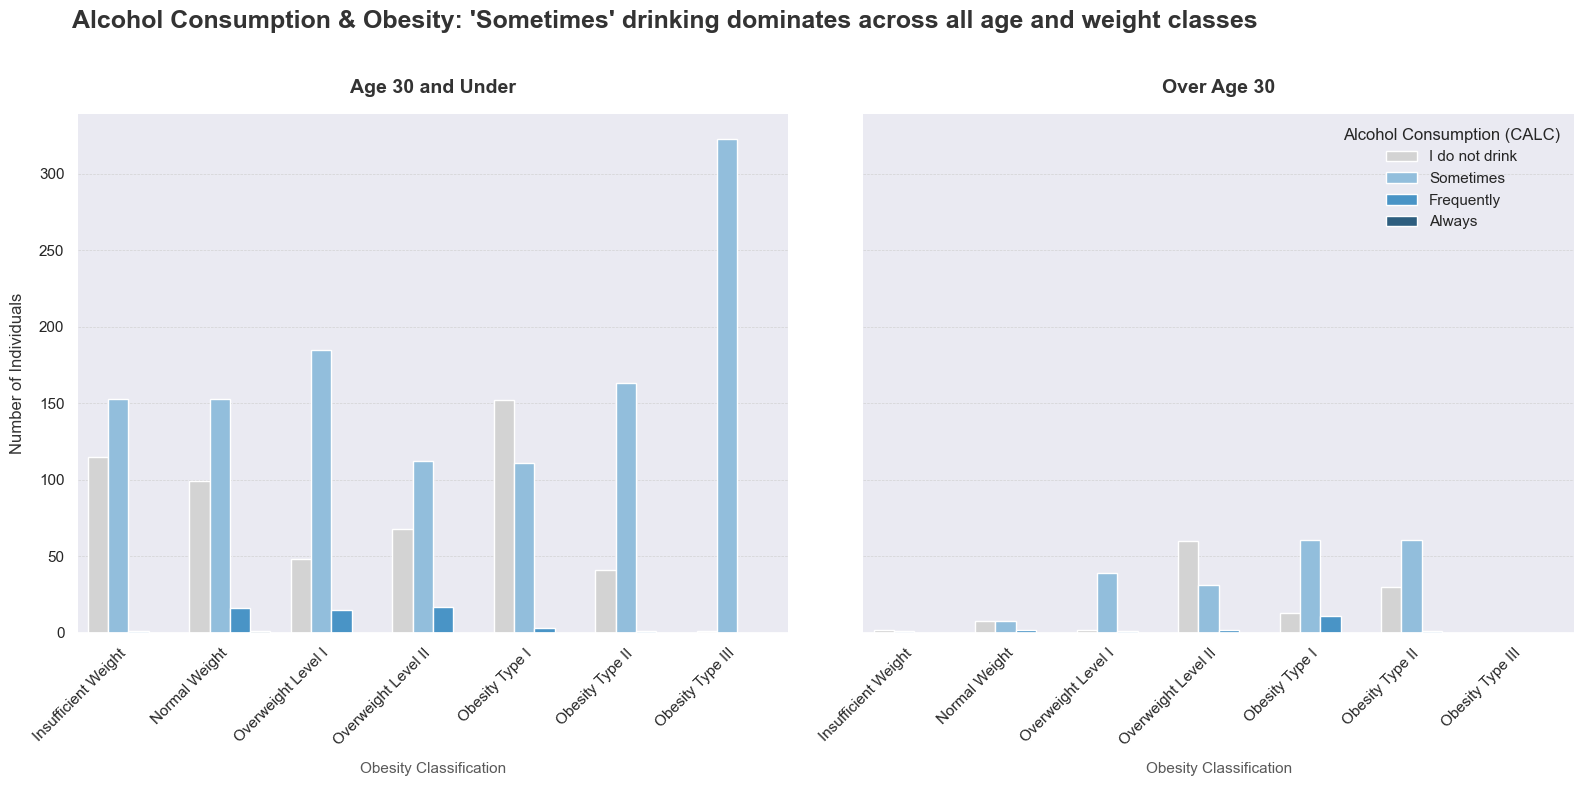

In [163]:
# --- 1. PREPROCESSING: MAP LABELS & SPLIT THE DATA ---
# Map the numeric CALC variable to human-readable strings
calc_mapping = {0: 'I do not drink', 1: 'Sometimes', 2: 'Frequently', 3: 'Always'}

# Create a new column for the plot to avoid overwriting your original data
obesity_df['CALC_Label'] = obesity_df['CALC'].map(calc_mapping)

# Create two separate dataframes for our subplots
df_under_30 = obesity_df[obesity_df['Age'] <= 30]
df_over_30 = obesity_df[obesity_df['Age'] > 30]

# --- 2. COLOR PALETTE & ORDERING ---
# Use a sequential palette to visually represent the increasing frequency
calc_palette = {
    'I do not drink': '#d3d3d3', # Light Gray (Baseline)
    'Sometimes': '#85c1e9',      # Light Blue
    'Frequently': '#3498db',     # Medium Blue
    'Always': '#21618c'          # Dark Blue
}

# Define the exact logical order for both the X-axis and the Hue (Legend)
obesity_order = [
    'Insufficient Weight', 'Normal Weight', 'Overweight Level I', 
    'Overweight Level II', 'Obesity Type I', 'Obesity Type II', 'Obesity Type III'
]
calc_order = ['I do not drink', 'Sometimes', 'Frequently', 'Always']

# --- 3. INITIALIZE SUBPLOTS ---
# sharey=True keeps the height scale identical so comparisons are accurate
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- 4. CREATE THE PLOTS (VERTICAL) ---
# Plot 1: 35 and Under (Left Axis)
sns.countplot(
    data=df_under_30,
    x='Obesity_Class', 
    hue='CALC_Label',
    palette=calc_palette,
    order=obesity_order,
    hue_order=calc_order,
    ax=axes[0]
)

# Plot 2: Over 35 (Right Axis)
sns.countplot(
    data=df_over_30,
    x='Obesity_Class', 
    hue='CALC_Label',
    palette=calc_palette,
    order=obesity_order,
    hue_order=calc_order,
    ax=axes[1]
)

# --- 5. SWD FORMATTING LOOP ---
# Apply the exact same clean styling to both subplots
for ax in axes:
    sns.despine(ax=ax, left=True, bottom=False)
    
    # HORIZONTAL gridlines for vertical bars
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
    ax.xaxis.grid(False) 
    ax.set_axisbelow(True)
    
    ax.set_xlabel("Obesity Classification", fontsize=11, color='#595959', labelpad=10)
    
    # Rotate the x-axis labels so they don't overlap
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 6. CLEAN UP LABELS & LEGENDS ---
# Set the Y-axis label only for the left chart (representing counts)
axes[0].set_ylabel("Number of Individuals", fontsize=12, color='#333333', labelpad=10)
axes[1].set_ylabel("")

# Remove the legend from the left chart, keep it on the right chart to avoid clutter
axes[0].legend().remove()
axes[1].legend(
    title="Alcohol Consumption (CALC)", 
    frameon=False, 
    loc='upper right' 
)

# --- 7. TITLES ---
# Subplot Titles
axes[0].set_title("Age 30 and Under", fontsize=14, color='#333333', fontweight='bold', pad=15)
axes[1].set_title("Over Age 30", fontsize=14, color='#333333', fontweight='bold', pad=15)

# Main Super Title for the entire figure
# (Update this text based on what the visual output actually reveals!)
fig.suptitle(
    "Alcohol Consumption & Obesity: 'Sometimes' drinking dominates across all age and weight classes", 
    fontsize=18, 
    fontweight='bold', 
    color='#333333', 
    x=0.05, 
    ha='left'
)

plt.tight_layout()
# Adjust top margin so the suptitle doesn't overlap the subplot titles
plt.subplots_adjust(top=0.85) 
plt.show()

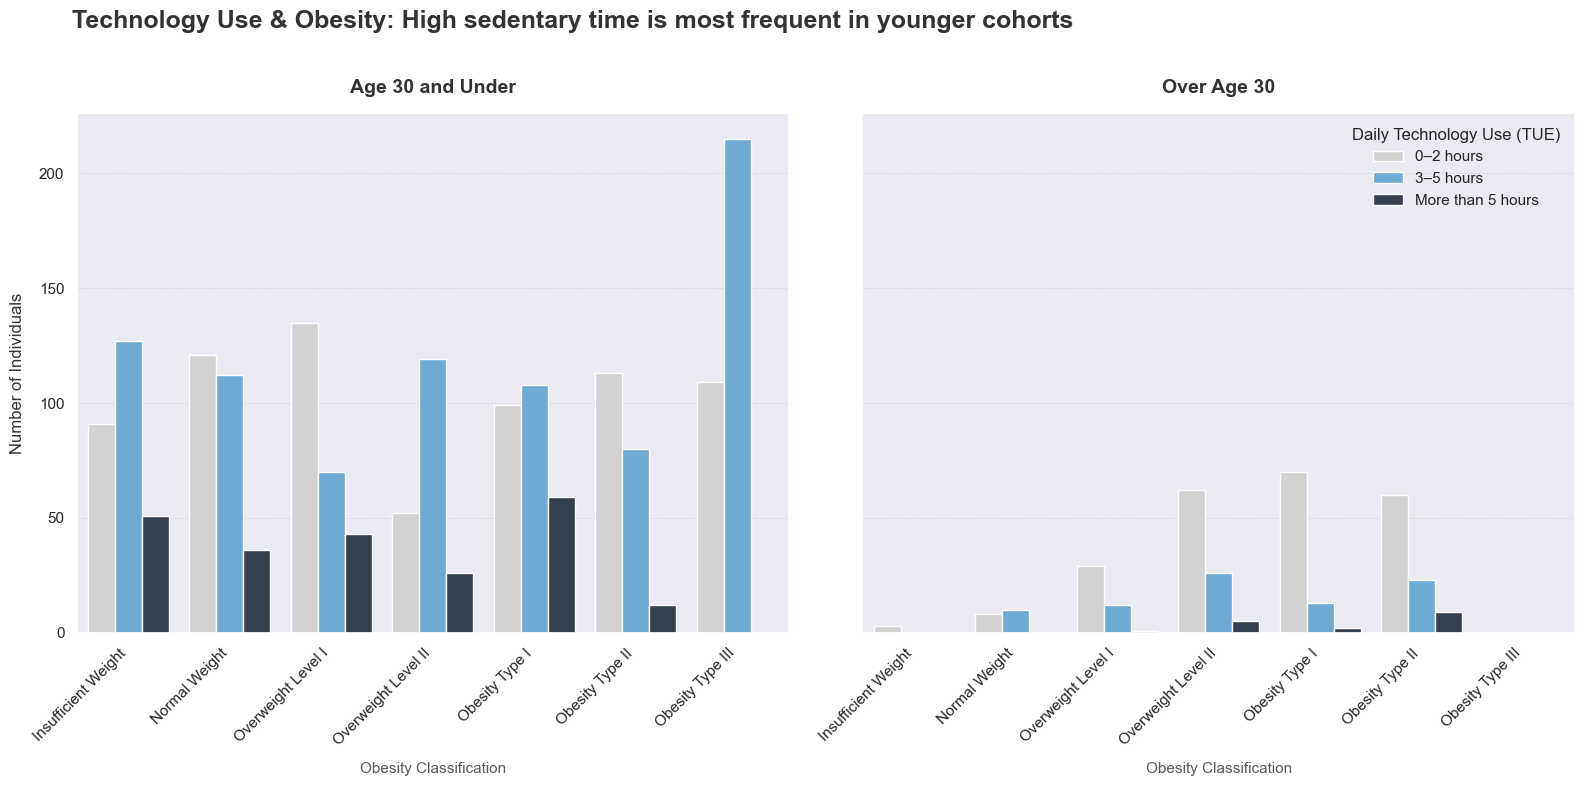

In [164]:
# Pre Process TUE
obesity_df['TUE'] = obesity_df['TUE'].round()

# Map the numeric TUE variable to human-readable strings
tue_mapping = {0: '0–2 hours', 1: '3–5 hours', 2: 'More than 5 hours'}

# Create a new column for the plot
obesity_df['TUE_Label'] = obesity_df['TUE'].map(tue_mapping)

# Create two separate dataframes for our subplots
df_under_30 = obesity_df[obesity_df['Age'] <= 30]
df_over_30 = obesity_df[obesity_df['Age'] > 30]

# --- 2. COLOR PALETTE & ORDERING ---
# Use a sequential blue-to-indigo palette to represent increasing sedentary time
tue_palette = {
    '0–2 hours': '#d1d1d1',         # Light Gray (Baseline)
    '3–5 hours': '#5dade2',         # Sky Blue
    'More than 5 hours': '#2e4053'  # Deep Navy
}

# Define the logical order for both the X-axis and the Hue (Legend)
obesity_order = [
    'Insufficient Weight', 'Normal Weight', 'Overweight Level I', 
    'Overweight Level II', 'Obesity Type I', 'Obesity Type II', 'Obesity Type III'
]
tue_order = ['0–2 hours', '3–5 hours', 'More than 5 hours']

# --- 3. INITIALIZE SUBPLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- 4. CREATE THE PLOT (VERTICAL) ---
# Plot 1: 30 and Under
sns.countplot(
    data=df_under_30,
    x='Obesity_Class', 
    hue='TUE_Label',
    palette=tue_palette,
    order=obesity_order,
    hue_order=tue_order,
    ax=axes[0]
)

# Plot 2: Over 30
sns.countplot(
    data=df_over_30,
    x='Obesity_Class', 
    hue='TUE_Label',
    palette=tue_palette,
    order=obesity_order,
    hue_order=tue_order,
    ax=axes[1]
)

# --- 5. SWD FORMATTING LOOP ---
for ax in axes:
    sns.despine(ax=ax, left=True, bottom=False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
    ax.xaxis.grid(False) 
    ax.set_axisbelow(True)
    ax.set_xlabel("Obesity Classification", fontsize=11, color='#595959', labelpad=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 6. CLEAN UP LABELS & LEGENDS ---
axes[0].set_ylabel("Number of Individuals", fontsize=12, color='#333333', labelpad=10)
axes[1].set_ylabel("")

axes[0].legend().remove()
axes[1].legend(
    title="Daily Technology Use (TUE)", 
    frameon=False, 
    loc='upper right' 
)

# --- 7. TITLES ---
axes[0].set_title("Age 30 and Under", fontsize=14, color='#333333', fontweight='bold', pad=15)
axes[1].set_title("Over Age 30", fontsize=14, color='#333333', fontweight='bold', pad=15)

fig.suptitle(
    "Technology Use & Obesity: High sedentary time is most frequent in younger cohorts", 
    fontsize=18, 
    fontweight='bold', 
    color='#333333', 
    x=0.05, 
    ha='left'
)

plt.tight_layout()
plt.subplots_adjust(top=0.85) 
plt.show()

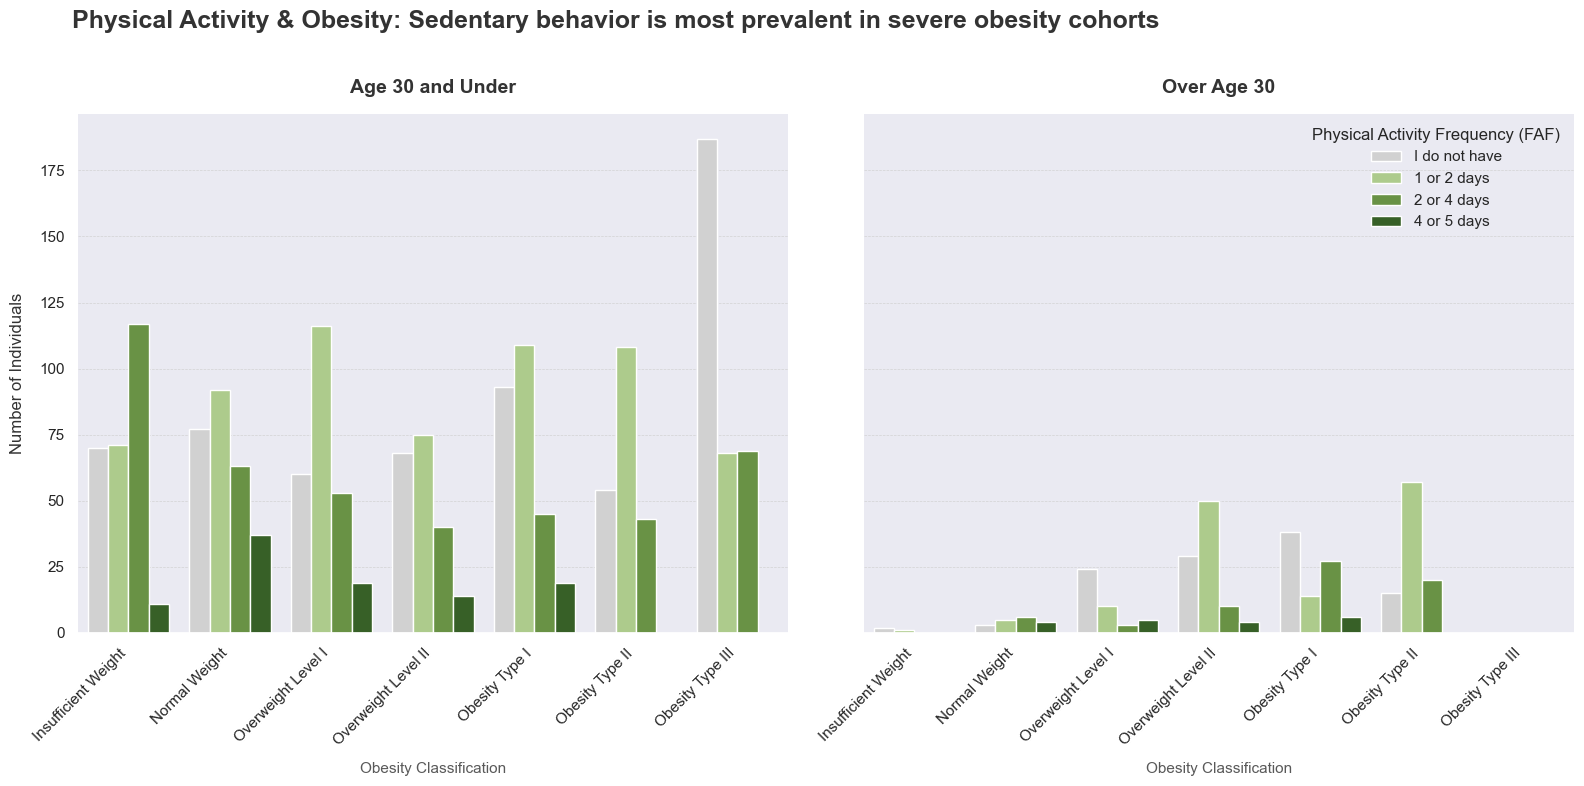

In [165]:
# Preprocess FAF
obesity_df['FAF'] = obesity_df.FAF.round()
faf_mapping = {0: 'I do not have', 1: '1 or 2 days', 2: '2 or 4 days', 3: '4 or 5 days'}

# Create a new column for the plot to preserve original data
obesity_df['FAF_Label'] = obesity_df['FAF'].map(faf_mapping)

# Create two separate dataframes for our subplots (Split at Age 35)
df_under_30 = obesity_df[obesity_df['Age'] <= 30]
df_over_30 = obesity_df[obesity_df['Age'] > 30]

# --- 2. COLOR PALETTE & ORDERING ---
# Using a green-themed sequential palette to represent increasing activity levels
faf_palette = {
    'I do not have': '#d1d1d1', # Light Gray (Baseline/Inactive)
    '1 or 2 days': '#aed581',   # Light Green
    '2 or 4 days': '#689f38',   # Medium Green
    '4 or 5 days': '#33691e'    # Dark Green (Highly Active)
}

# Define the logical order for the X-axis and the legend
obesity_order = [
    'Insufficient Weight', 'Normal Weight', 'Overweight Level I', 
    'Overweight Level II', 'Obesity Type I', 'Obesity Type II', 'Obesity Type III'
]
faf_order = ['I do not have', '1 or 2 days', '2 or 4 days', '4 or 5 days']

# --- 3. INITIALIZE SUBPLOTS ---
# sharey=True ensures the vertical scale is identical for accurate comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- 4. CREATE THE PLOTS (VERTICAL) ---
# Plot 1: 30 and Under
sns.countplot(
    data=df_under_30,
    x='Obesity_Class', 
    hue='FAF_Label',
    palette=faf_palette,
    order=obesity_order,
    hue_order=faf_order,
    ax=axes[0]
)

# Plot 2: Over 30
sns.countplot(
    data=df_over_30,
    x='Obesity_Class', 
    hue='FAF_Label',
    palette=faf_palette,
    order=obesity_order,
    hue_order=faf_order,
    ax=axes[1]
)

# --- 5. SWD FORMATTING LOOP ---
for ax in axes:
    sns.despine(ax=ax, left=True, bottom=False)
    
    # Horizontal gridlines to help gauge bar height
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
    ax.xaxis.grid(False) 
    ax.set_axisbelow(True)
    
    ax.set_xlabel("Obesity Classification", fontsize=11, color='#595959', labelpad=10)
    
    # Rotate the x-axis labels 45 degrees for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# --- 6. CLEAN UP LABELS & LEGENDS ---
axes[0].set_ylabel("Number of Individuals", fontsize=12, color='#333333', labelpad=10)
axes[1].set_ylabel("")

# Single legend on the right plot to reduce redundancy
axes[0].legend().remove()
axes[1].legend(
    title="Physical Activity Frequency (FAF)", 
    frameon=False, 
    loc='upper right' 
)

# --- 7. TITLES ---
axes[0].set_title("Age 30 and Under", fontsize=14, color='#333333', fontweight='bold', pad=15)
axes[1].set_title("Over Age 30", fontsize=14, color='#333333', fontweight='bold', pad=15)

# Main Super Title
fig.suptitle(
    "Physical Activity & Obesity: Sedentary behavior is most prevalent in severe obesity cohorts", 
    fontsize=18, 
    fontweight='bold', 
    color='#333333', 
    x=0.05, 
    ha='left'
)

plt.tight_layout()
# Adjust top margin so the suptitle doesn't overlap the plot content
plt.subplots_adjust(top=0.85) 
plt.savefig('Figure_4')
plt.show()
